In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mesa_reader import MesaData
from astropy import units as u
from astropy.constants import G
import scipy.constants as const
import os
import pickle
import sys
import pandas as pd
from matplotlib.colors import TwoSlopeNorm 
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    "font.size": 16,             
    "axes.titlesize": 20,        
    "axes.labelsize": 18,        
    "xtick.labelsize": 16,       
    "ytick.labelsize": 16,       
    "legend.fontsize": 16,       
    "legend.title_fontsize": 18, 
    "figure.titlesize": 22      
})


In [2]:
def load_csv_fortran(filename):
    with open(filename, 'r') as f:
        header = f.readline().strip()
        col_names = header.split(',')
        lines = [line.replace('D+', 'E+').replace('D-', 'E-') for line in f.readlines()]
    data = np.genfromtxt(lines, delimiter=',')
    return col_names, data

# Planet characteristics and constants

In [4]:
Minit = np.array([0.2, 0.5, 1.0, 5.0, 10.0])  # Mj
Tinit = np.array([300, 500, 1000])  # K
ages_target = np.array([5.0])  # in Gyr. I choose the age at which I want information about the planets
z = 0.017 # metallicity
core_mass = "Mcore=0.01Me_homogeneous"
#core_mass = "Mcore=10Me"

# Luminosity vs Mass plots at specific age

I summarize the luminosity of planets with different masses and equilibrium temperatures. In the cell below I loop over all different combinations of planet mass, temperature and core mass. I calculate the luminosity of the planets by interpolating the data at a specific age chosen before. I summarize this in the plot and table below per mass and per temperature. In the table I show the mean, standard deviation, fractional difference (MU) and absolute average difference (abs).

No MESA file for 0.2Mj, 300K
No Completo file for 0.2Mj and 300K
No MESA file for 0.5Mj, 300K
No MESA file for 1.0Mj, 300K
No MESA file for 5.0Mj, 300K
Using fallback radius 1.0 Rj for M=5.0 Mj, T=300 K, Z=0.017
No CEPAM file found for M=10.0 Mj, T=300 K at 2.0Rj or 1.0Rj
No MESA file for 0.2Mj, 500K
No Completo file for 0.2Mj and 500K
No MESA file for 0.5Mj, 500K
Using fallback radius 1.0 Rj for M=5.0 Mj, T=500 K, Z=0.017
No CEPAM file found for M=10.0 Mj, T=500 K at 2.0Rj or 1.0Rj
No MESA file for 0.2Mj, 1000K
No Completo file for 0.2Mj and 1000K
No MESA file for 0.5Mj, 1000K
Using fallback radius 1.0 Rj for M=5.0 Mj, T=1000 K, Z=0.017
No CEPAM file found for M=10.0 Mj, T=1000 K at 2.0Rj or 1.0Rj


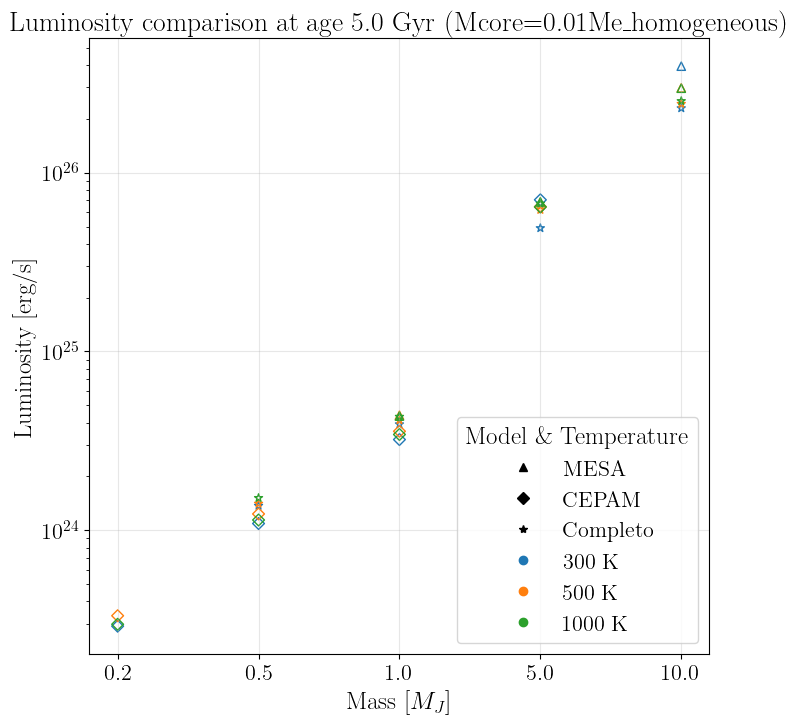


=== Combined Luminosity Metrics at Age 5.0 Gyr ===

Temp/Mass   Metric           0.2       0.5       1.0       5.0      10.0     Row Avg
------------------------------------------------------------------------------------
300 K       mean       2.906e+23 1.231e+24 3.565e+24 5.974e+25 3.119e+26   7.534e+25
            std              N/A 1.403e+23 3.502e+23 1.077e+25 8.238e+25   2.341e+25
            MU               N/A    11.40%     9.82%    18.02%    26.42%      16.42%
            abs              N/A 2.807e+23 7.005e+23 2.153e+25 1.648e+26   4.682e+25

500 K       mean       3.325e+23 1.321e+24 4.033e+24 6.481e+25 2.703e+26   6.816e+25
            std              N/A 8.736e+22 3.417e+23 2.448e+24 2.771e+25   7.647e+24
            MU               N/A     6.61%     8.47%     3.78%    10.25%       7.28%
            abs              N/A 1.747e+23 5.482e+23 3.984e+24 5.542e+25   1.503e+25

1000 K      mean       2.979e+23 1.328e+24 4.032e+24 6.674e+25 2.742e+26   6.932e+25
          

In [6]:

for age_value in ages_target:
    # Plotting
    mass_positions = np.arange(len(Minit))
    mass_to_x = dict(zip(Minit, mass_positions))
    colors = {300: "tab:blue", 500: "tab:orange", 1000: "tab:green"}
    plt.figure(figsize=(8,8))
    plt.xlabel("Mass [$M_J$]")
    plt.ylabel("Luminosity [erg/s]")
    plt.yscale("log")
    plt.title(f"Luminosity comparison at age {age_value} Gyr ({core_mass}) ")
    plt.grid(alpha=0.3)

    # Table
    table = {t: {} for t in Tinit} 
    std_table = {}
    avg_luminosity_table = {}
    combined = {}

    for t in Tinit:
        color = colors[t]
        std_table[t] = {}
        avg_luminosity_table[t] = {}
        combined[t] = {}
        for m in Minit:

################# MESA
            mesa_file_history = f"/data/MESA/inert_core_planets/{core_mass}/inert_core_models_{t}K/evolve_models_{t}K/inert_core_evolved/planet_evolve_{m}_Mj_2.0_Rj_zbar={z}_inert_core_s=11.0.history"
            try:
                mesa_data_history = np.loadtxt(mesa_file_history, skiprows=6)
                age_m = mesa_data_history[:, 2]
                age_m = age_m/(10**9)
                luminosity_m = ((mesa_data_history[:, 7] * u.L_sun).to(u.erg / u.s)).value
                luminosity_m_t = np.interp(age_value, age_m, luminosity_m) \
                             if age_value <= age_m.max() else None
            except FileNotFoundError:
                luminosity_m_t = None
                print(f"No MESA file for {m}Mj, {t}K")
                

################ CEPAM
            file_20 = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_2.0Rj_{z}z_0.01s/mev_ev.csv"
            file_10 = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_1.0Rj_{z}z_0.01s/mev_ev.csv"
            
            cepam_file_ev = None
            
            # Check 2.0 Rj
            if os.path.exists(file_20):
                cepam_file_ev = file_20
            else:
                # Fallback to 1.0 Rj
                if os.path.exists(file_10):
                    cepam_file_ev = file_10
                    print(f"Using fallback radius 1.0 Rj for M={m} Mj, T={t} K, Z={z}")
                else:
                    print(f"No CEPAM file found for M={m} Mj, T={t} K at 2.0Rj or 1.0Rj")
                    luminosity_c_t = None

            if cepam_file_ev is not None:
                col_names, cepam_data_ev = load_csv_fortran(cepam_file_ev)
            
                age_c = cepam_data_ev[:,0] / 1e3  # Myr to Gyr
                luminosity_c = (cepam_data_ev[:,8] * (u.erg / u.s)).value # in erg/s
                luminosity_c_t = np.interp(age_value, age_c, luminosity_c) \
                                if age_value <= age_c.max() else None


################ Completo
            if core_mass == "Mcore=0.01Me_homogeneous":
                mcore = 0.01
            if core_mass == "Mcore=10Me":
                mcore = 10
                
            completo_file_ev = f"/data/Completo21/Teq{t}K/{m}Mj_Mcore_{mcore}/evolution_000.outputdat"
            try:
                completo_data_ev = np.loadtxt(completo_file_ev)
                age_cp = completo_data_ev[:, 1] # in years
                age_cp = age_cp / (10**9) # in Gyr
                luminosity_cp = (completo_data_ev[:, 11] * u.L_sun).to(u.erg / u.s)
                luminosity_cp_t = np.interp(age_value, age_cp, luminosity_cp)
                luminosity_cp_t = luminosity_cp_t.value
    
            except FileNotFoundError:
                luminosity_cp_t = None    
                print(f"No Completo file for {m}Mj and {t}K")


############## Absolute average differences
            luminosities = {"MESA": luminosity_m_t, "CEPAM": luminosity_c_t, "Completo": luminosity_cp_t}
            abs_diffs = {}
            if luminosities["Completo"] is not None and luminosities["CEPAM"] is not None:
                abs_diffs["|Completo - CEPAM|"] = abs(luminosities["Completo"] - luminosities["CEPAM"])
            if luminosities["Completo"] is not None and luminosities["MESA"] is not None:
                abs_diffs["|Completo - MESA|"] = abs(luminosities["Completo"] - luminosities["MESA"])
            if luminosities["MESA"] is not None and luminosities["CEPAM"] is not None:
                abs_diffs["|MESA - CEPAM|"] = abs(luminosities["MESA"] - luminosities["CEPAM"])

            if len(abs_diffs) > 0:
                avg_abs_diff = sum(abs_diffs.values()) / len(abs_diffs)
            else:
                avg_abs_diff = None

            if avg_abs_diff is not None:
                table[t][m] = avg_abs_diff
            else:
                table[t][m] = None

            
#################### Standard deviation of the luminosities
            vals = [r for r in luminosities.values() if r is not None]
            
            if len(vals) > 1:
                std_luminosity = np.std(vals)
            else:
                std_luminosity = None
            
            if t not in std_table:
                std_table[t] = {}
            
            std_table[t][m] = std_luminosity
            
            
##################### Average luminosities
            vals = [r for r in luminosities.values() if r is not None]
            
            if vals:
                avg_luminosity = sum(vals) / len(vals)
            else:
                avg_luminosity = None
                
            avg_luminosity_table[t][m] = avg_luminosity
            mean_val = avg_luminosity_table[t][m]
            std_val = std_table[t][m]
            
################# Fractional uncertainty
            if mean_val is not None and std_val is not None and mean_val != 0:
                frac_val = std_val / mean_val
            else:
                frac_val = None
            
################### Store numbers in summary table
            combined[t][m] = {
                "mean": mean_val,
                "std": std_val,
                "MU": frac_val,
                "abs": table[t][m]
            }

##################### Plotting
            if luminosity_m_t is not None:
                plt.scatter(mass_to_x[m], luminosity_m_t,  marker="^", facecolors='none', edgecolor=color)
            if luminosity_c_t is not None:
                plt.scatter(mass_to_x[m], luminosity_c_t, marker="D", facecolors='none', edgecolor=color)
            if luminosity_cp_t is not None:
                plt.scatter(mass_to_x[m], luminosity_cp_t, marker="*", facecolors='none', edgecolor=color)
           

    # Plot
    plt.scatter([], [], marker="^", label="MESA")
    plt.scatter([], [], marker="D", label="CEPAM")
    plt.scatter([], [], marker="*", label="Completo")
    plt.xticks(mass_positions, Minit)
    
    model_handles = [
        plt.Line2D([], [], marker="^", color="black", linestyle="None", label="MESA"),
        plt.Line2D([], [], marker="D", color="black", linestyle="None", label="CEPAM"),
        plt.Line2D([], [], marker="*", color="black", linestyle="None", label="Completo"),
    ]
    temp_handles = [
        plt.Line2D([], [], marker="o", color=colors[300], linestyle="None", label="300 K"),
        plt.Line2D([], [], marker="o", color=colors[500], linestyle="None", label="500 K"),
        plt.Line2D([], [], marker="o", color=colors[1000], linestyle="None", label="1000 K"),
    ]
    all_handles = model_handles + temp_handles
    plt.legend(handles=all_handles, title="Model \& Temperature", loc="lower right")
    plt.show()


################# Summary table
    
    metrics = ["mean", "std", "MU", "abs"]  
    
    # Calculate row averages
    row_avg = {t: {} for t in Tinit}
    for t in Tinit:
        for metric in metrics:
            vals = [
                combined[t][m][metric]
                for m in Minit
                if combined[t][m][metric] is not None
            ]
            row_avg[t][metric] = sum(vals)/len(vals) if vals else None
    
    # Calculate column averages
    col_avg = {m: {} for m in Minit}
    for m in Minit:
        for metric in metrics:
            vals = [
                combined[t][m][metric]
                for t in Tinit
                if combined[t][m][metric] is not None
            ]
            col_avg[m][metric] = sum(vals)/len(vals) if vals else None
    
    # Calculate grand averages
    grand_avg = {}
    for metric in metrics:
        vals = [
            combined[t][m][metric]
            for t in Tinit
            for m in Minit
            if combined[t][m][metric] is not None
        ]
        grand_avg[metric] = sum(vals)/len(vals) if vals else None
    
    
    print(f"\n=== Combined Luminosity Metrics at Age {age_value} Gyr ===\n")
    
    # Make table header    
    header = "Temp/Mass".ljust(12) + "Metric".ljust(10)
    for m in Minit:
        header += f"{m:>10}"
    header += f"{'Row Avg':>12}"
    print(header)
    print("-" * len(header))
    
    

    # Temperature numbers    
    for t in Tinit:
    
        # mean row
        row = f"{t} K".ljust(12) + "mean".ljust(10)
        for m in Minit:
            val = combined[t][m]["mean"]
            row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
        ravg = row_avg[t]["mean"]
        row += f"{ravg:>12.3e}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
        # std row
        row = " ".ljust(12) + "std".ljust(10)
        for m in Minit:
            val = combined[t][m]["std"]
            row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
        ravg = row_avg[t]["std"]
        row += f"{ravg:>12.3e}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
        # MU row as percentage 
        row = " ".ljust(12) + "MU".ljust(10)
        for m in Minit:
            val = combined[t][m]["MU"]
            row += f"{val*100:>9.2f}%" if val is not None else f"{'N/A':>10}"
        ravg = row_avg[t]["MU"]
        row += f"{ravg*100:>11.2f}%" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
        # abs row
        row = " ".ljust(12) + "abs".ljust(10)
        for m in Minit:
            val = combined[t][m]["abs"]
            row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
        ravg = row_avg[t]["abs"]
        row += f"{ravg:>12.3e}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
        print() 
    
    
    
    # Mass numbers
    print("-" * len(header))
    
    # mean column
    row = "Col Avg".ljust(12) + "mean".ljust(10)
    for m in Minit:
        val = col_avg[m]["mean"]
        row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg['mean']:>12.3e}"
    print(row)
    
    # std column
    row = " ".ljust(12) + "std".ljust(10)
    for m in Minit:
        val = col_avg[m]["std"]
        row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg['std']:>12.3e}"
    print(row)
    
    # MU column
    row = " ".ljust(12) + "MU".ljust(10)
    for m in Minit:
        val = col_avg[m]["MU"]
        row += f"{val*100:>9.2f}%" if val is not None else f"{'N/A':>10}"
    gavg = grand_avg["MU"]
    row += f"{gavg*100:>11.2f}%" if gavg is not None else f"{'N/A':>12}"
    print(row)
    
    # abs column
    row = " ".ljust(12) + "abs".ljust(10)
    for m in Minit:
        val = col_avg[m]["abs"]
        row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg['abs']:>12.3e}"
    print(row)
    


# Luminosity vs Mass plots at three ages

I do the same as in the cell above but now for three ages instead of one. I made a function that can plot the luminosity vs mass for different ages. There is no summary table printed here. If I want a summary table for a specific age I do this in the cell above. 

No MESA file for 0.2Mj, 300K
No Completo file for 0.2Mj and 300K
No MESA file for 0.5Mj, 300K
No MESA file for 1.0Mj, 300K
No MESA file for 5.0Mj, 300K
Using fallback radius 1.0 Rj for M=5.0 Mj, T=300 K, Z=0.017
No CEPAM file found for M=10.0 Mj, T=300 K at 2.0Rj or 1.0Rj
No MESA file for 0.2Mj, 500K
No Completo file for 0.2Mj and 500K
No MESA file for 0.5Mj, 500K
Using fallback radius 1.0 Rj for M=5.0 Mj, T=500 K, Z=0.017
No CEPAM file found for M=10.0 Mj, T=500 K at 2.0Rj or 1.0Rj
No MESA file for 0.2Mj, 1000K
No Completo file for 0.2Mj and 1000K
No MESA file for 0.5Mj, 1000K
Using fallback radius 1.0 Rj for M=5.0 Mj, T=1000 K, Z=0.017
No CEPAM file found for M=10.0 Mj, T=1000 K at 2.0Rj or 1.0Rj
No MESA file for 0.2Mj, 300K
No Completo file for 0.2Mj and 300K
No MESA file for 0.5Mj, 300K
No MESA file for 1.0Mj, 300K
No MESA file for 5.0Mj, 300K
Using fallback radius 1.0 Rj for M=5.0 Mj, T=300 K, Z=0.017
No CEPAM file found for M=10.0 Mj, T=300 K at 2.0Rj or 1.0Rj
No MESA file for 0.

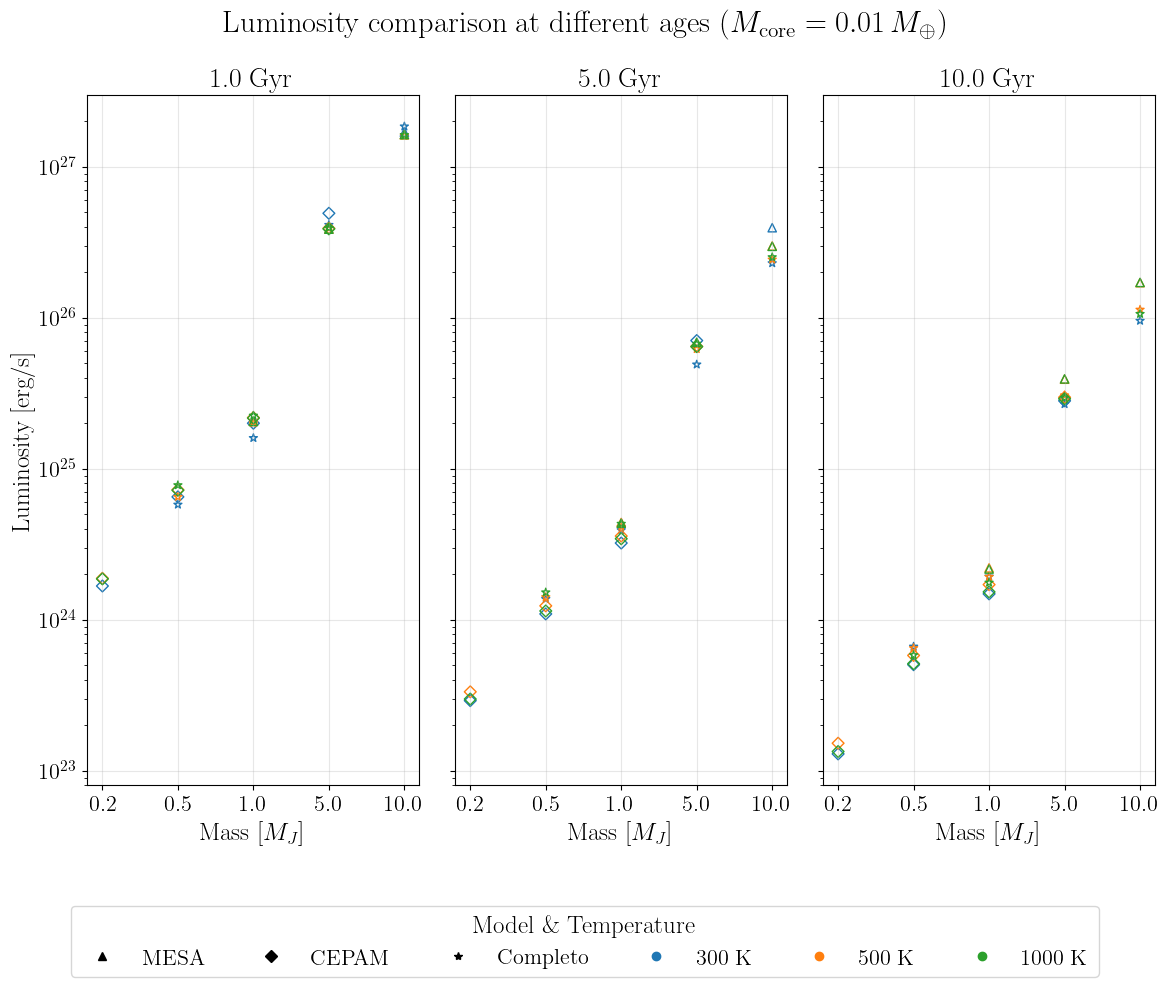

In [8]:
ages_target = np.array([1.0, 5.0, 10.0])  # Gyr


def plot_luminosity_vs_mass(ax, age_value, Minit, Tinit, z,
                        mass_to_x, mass_positions, colors):

    for t in Tinit:
        color = colors[t]

        for m in Minit:

################ MESA
            mesa_file_history = f"/data/MESA/inert_core_planets/{core_mass}/inert_core_models_{t}K/evolve_models_{t}K/inert_core_evolved/planet_evolve_{m}_Mj_2.0_Rj_zbar={z}_inert_core_s=11.0.history"
            try:
                mesa_data_history = np.loadtxt(mesa_file_history, skiprows=6)
                age_m = mesa_data_history[:, 2] / 1e9
                luminosity_m = (mesa_data_history[:, 7] * u.L_sun).to(u.erg / u.s)

                luminosity_m_t = np.interp(age_value, age_m, luminosity_m) \
                             if age_value <= age_m.max() else None
            except FileNotFoundError:
                luminosity_m_t = None
                print(f"No MESA file for {m}Mj, {t}K")

################ CEPAM
            file_20 = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_2.0Rj_{z}z_0.01s/mev_ev.csv"
            file_10 = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_1.0Rj_{z}z_0.01s/mev_ev.csv"
            
            if os.path.exists(file_20):
                cepam_file_ev = file_20
            elif os.path.exists(file_10):
                cepam_file_ev = file_10
                print(f"Using fallback radius 1.0 Rj for M={m} Mj, T={t} K, Z={z}")
            else:
                cepam_file_ev = None
                luminosity_c_t = None
                print(f"No CEPAM file found for M={m} Mj, T={t} K at 2.0Rj or 1.0Rj")

            if cepam_file_ev is not None:
                col_names, cepam_data_ev = load_csv_fortran(cepam_file_ev)
                age_c = cepam_data_ev[:, 0] / 1e3
                luminosity_c = cepam_data_ev[:,8] * (u.erg / u.s) # in erg/s
                luminosity_c_t = np.interp(age_value, age_c, luminosity_c) \
                                if age_value <= age_c.max() else None

################ Completo
            if core_mass == "Mcore=0.01Me_homogeneous":
                mcore = 0.01
            if core_mass == "Mcore=10Me":
                mcore = 10
                
            completo_file_ev = f"/data/Completo21/Teq{t}K/{m}Mj_Mcore_{mcore}/evolution_000.outputdat"
            try:
                completo_data_ev = np.loadtxt(completo_file_ev)
                age_cp = completo_data_ev[:, 1] # in years
                age_cp = age_cp / (10**9) # in Gyr
                luminosity_cp = (completo_data_ev[:, 11] * u.L_sun).to(u.erg / u.s)
                luminosity_cp_t = np.interp(age_value, age_cp, luminosity_cp)
                luminosity_cp_t = luminosity_cp_t.value
    
            except FileNotFoundError:
                luminosity_cp_t = None    
                print(f"No Completo file for {m}Mj and {t}K")

################ Plotting
            if luminosity_m_t is not None:
                ax.scatter(mass_to_x[m], luminosity_m_t, marker="^",
                           facecolors='none', edgecolor=color)
            if luminosity_c_t is not None:
                ax.scatter(mass_to_x[m], luminosity_c_t, marker="D",
                           facecolors='none', edgecolor=color)
            if luminosity_cp_t is not None:
                ax.scatter(mass_to_x[m], luminosity_cp_t, marker="*",
                           facecolors='none', edgecolor=color)

    # Axis formatting
    ax.set_xticks(mass_positions)
    ax.set_xticklabels(Minit)
    ax.set_title(f"{age_value} Gyr")
    ax.grid(alpha=0.3)


# Plotting
fig, axes = plt.subplots(1, len(ages_target), figsize=(12, 10), sharey=True)
if core_mass == "Mcore=0.01Me_homogeneous":
    fig.suptitle(f"Luminosity comparison at different ages ($M_{{\\mathrm{{core}}}} = 0.01 \\, M_{{\\oplus}}$)", fontsize=22)
if core_mass == "Mcore=10Me":
    fig.suptitle(f"Luminosity comparison at different ages ($M_{{\\mathrm{{core}}}} = 10 \\, M_{{\\oplus}}$)", fontsize=22)

mass_positions = np.arange(len(Minit))
mass_to_x = dict(zip(Minit, mass_positions))
colors = {300: "tab:blue", 500: "tab:orange", 1000: "tab:green"}

for ax, age_value in zip(axes, ages_target):
    plot_luminosity_vs_mass(ax, age_value, Minit, Tinit, z,
                        mass_to_x, mass_positions, colors)
    ax.set_xlabel("Mass [$M_J$]")
axes[0].set_ylabel("Luminosity [erg/s]")
axes[0].set_yscale("log")

# Shared legend
model_handles = [
    plt.Line2D([], [], marker="^", color="black", linestyle="None", label="MESA"),
    plt.Line2D([], [], marker="D", color="black", linestyle="None", label="CEPAM"),
    plt.Line2D([], [], marker="*", color="black", linestyle="None", label="Completo"),
]
temp_handles = [
    plt.Line2D([], [], marker="o", color=colors[300], linestyle="None", label="300 K"),
    plt.Line2D([], [], marker="o", color=colors[500], linestyle="None", label="500 K"),
    plt.Line2D([], [], marker="o", color=colors[1000], linestyle="None", label="1000 K"),
]

handles = model_handles + temp_handles
labels = [h.get_label() for h in handles]

fig.legend(handles, labels, title="Model \& Temperature",
           loc="lower center", ncol=6)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()


# Heat plots

I want to know how much the three different codes (MESA, CEPAM, Completo) differ from each other. I visualize this in heat plots. First I write functions to make the heatplots and to calculate the (absolute) mean and standard deviation.

In [10]:
def plot_pairwise_heatmaps(pairwise, Tinit, Minit, age_value, core_mass, z):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    if core_mass == "Mcore=0.01Me_homogeneous":
        fig.suptitle(f"Luminosity differences at {age_value} Gyr ($M_{{\\mathrm{{core}}}} = 0.01 \\, M_{{\\oplus}}$)", fontsize=22)
    if core_mass == "Mcore=10Me":
        fig.suptitle(f"Luminosity differences at {age_value} Gyr ($M_{{\\mathrm{{core}}}} = 10 \\, M_{{\\oplus}}$)", fontsize=22)

    keys = ["MESA-CEPAM", "MESA-Completo", "CEPAM-Completo"]

    all_values = []
    for key in keys:
        for t in Tinit:
            for m in Minit:
                val = pairwise[key][t][m]
                if val is not None:
                    all_values.append(val)
    
    # Symmetric linear range
    abs_max = max(abs(min(all_values)), abs(max(all_values)))
    norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

    for ax, key in zip(axes, keys):
        mat = np.array([
            [pairwise[key][t][m] if pairwise[key][t][m] is not None else np.nan for m in Minit]
            for t in Tinit
        ])
    
        im = ax.imshow(
            mat,
            cmap="coolwarm",
            norm=norm,
            aspect="auto"
        )
    
        for i in range(len(Tinit)):
            for j in range(len(Minit)):
                val = mat[i, j]
                if not np.isnan(val):
                    ax.text(
                        j, i, f"{val:.3f}",
                        ha="center", va="center",
                        color="black",
                        fontsize=12,
                        fontweight="bold"
                    )
        # Plotting
        ax.set_title(f"{key}")
        ax.set_xticks(range(len(Minit)))
        ax.set_xticklabels(Minit)
        ax.set_yticks(range(len(Tinit)))
        ax.set_yticklabels(Tinit)
        ax.invert_yaxis()
        ax.set_xlabel("Mass [$M_J$]")
        ax.set_ylabel("Temperature [K]")
    
        ax.set_xticks(np.arange(len(Minit)+1)-0.5, minor=True)
        ax.set_yticks(np.arange(len(Tinit)+1)-0.5, minor=True)
        ax.grid(which="minor", color="black", linewidth=0.5)
        ax.tick_params(which="minor", bottom=False, left=False)

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    formatter = ScalarFormatter()
    formatter.set_powerlimits((-2, 2))
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.set_label("Relative luminosity difference")
    plt.show()

def compute_pairwise_stats(pairwise, Tinit, Minit):
    stats = {}

    for key in ["MESA-CEPAM", "MESA-Completo", "CEPAM-Completo"]:
        values = []

        for t in Tinit:
            for m in Minit:
                val = pairwise[key][t][m]
                if val is not None:
                    values.append(val)

        values = np.array(values)

        stats[key] = {
            "mean_signed": np.mean(values),          
            "mean_abs": np.mean(np.abs(values)),     
            "std_signed": np.std(values),           
            "n_points": len(values)
        }

    return stats


With the functions above I can now plot the heatplots and print the statistics. I also print three tables with the mean, standard deviation and average absolute difference, as well as the same summary table I printed before. 

No MESA file for 0.2Mj, 300K
No Completo file for 0.2Mj and 300K
No MESA file for 0.5Mj, 300K
No MESA file for 1.0Mj, 300K
No MESA file for 5.0Mj, 300K
Using fallback radius 1.0 Rj for M=5.0 Mj, T=300 K, Z=0.017
No CEPAM file found for M=10.0 Mj, T=300 K at 2.0Rj or 1.0Rj
No MESA file for 0.2Mj, 500K
No Completo file for 0.2Mj and 500K
No MESA file for 0.5Mj, 500K
Using fallback radius 1.0 Rj for M=5.0 Mj, T=500 K, Z=0.017
No CEPAM file found for M=10.0 Mj, T=500 K at 2.0Rj or 1.0Rj
No MESA file for 0.2Mj, 1000K
No Completo file for 0.2Mj and 1000K
No MESA file for 0.5Mj, 1000K
Using fallback radius 1.0 Rj for M=5.0 Mj, T=1000 K, Z=0.017
No CEPAM file found for M=10.0 Mj, T=1000 K at 2.0Rj or 1.0Rj


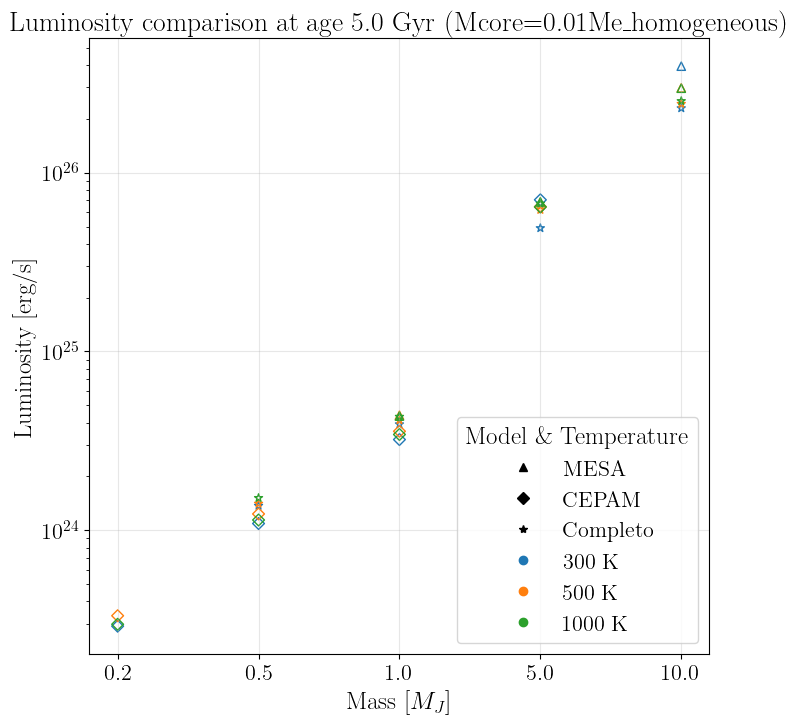

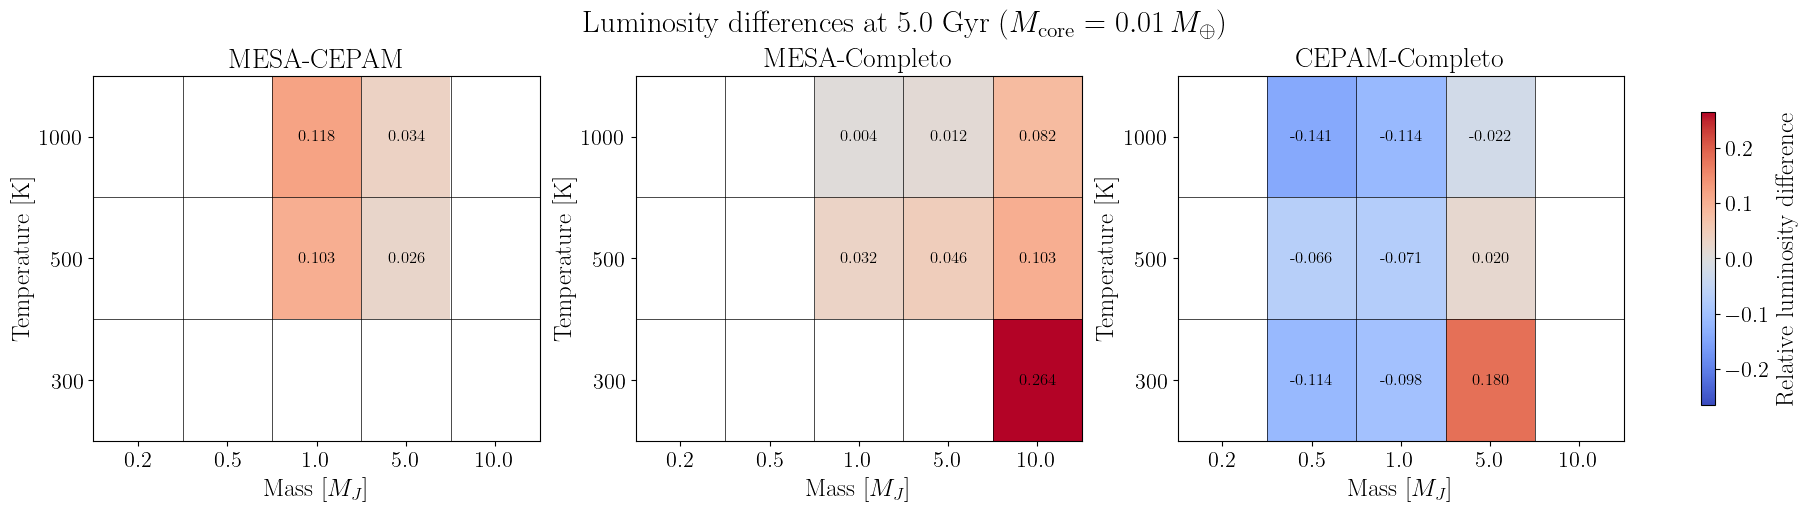


=== Average Absolute Differences at Age 5.0 Gyr ===

Temp/Mass          0.2       0.5       1.0       5.0      10.0     Row Avg
--------------------------------------------------------------------------
300 K              N/A 2.807e+23 7.005e+23 2.153e+25 1.648e+26   4.682e+25
500 K              N/A 1.747e+23 5.482e+23 3.984e+24 5.542e+25   1.503e+25
1000 K             N/A 3.746e+23 6.130e+23 2.983e+24 4.518e+25   1.229e+25
--------------------------------------------------------------------------
Col Avg            N/A 2.766e+23 6.206e+23 9.499e+24 8.845e+25   2.471e+25

=== Standard Deviation of luminosities at Age 5.0 Gyr ===

Temp/Mass          0.2       0.5       1.0       5.0      10.0     Row Avg
--------------------------------------------------------------------------
300 K              N/A 1.403e+23 3.502e+23 1.077e+25 8.238e+25   2.341e+25
500 K              N/A 8.736e+22 3.417e+23 2.448e+24 2.771e+25   7.647e+24
1000 K             N/A 1.873e+23 4.248e+23 1.850e+24 2.259e+2

In [11]:
ages_target = np.array([5.0])  # Gyr
pairwise_signed = {}
luminosities_table = {}

for age_value in ages_target:
    # Plotting
    mass_positions = np.arange(len(Minit))
    mass_to_x = dict(zip(Minit, mass_positions))
    colors = {300: "tab:blue", 500: "tab:orange", 1000: "tab:green"}
    plt.figure(figsize=(8,8))
    plt.xlabel("Mass [$M_J$]")
    plt.ylabel("Luminosity [erg/s]")
    plt.yscale("log")
    plt.title(f"Luminosity comparison at age {age_value} Gyr ({core_mass}) ")
    plt.grid(alpha=0.3)

    # Table
    table = {t: {} for t in Tinit} 
    std_table = {}
    avg_luminosity_table = {}
    combined = {}
    luminosities_table[age_value] = {t: {} for t in Tinit}

    pairwise_signed[age_value] = {
        "MESA-CEPAM": {t: {} for t in Tinit},
        "MESA-Completo": {t: {} for t in Tinit},
        "CEPAM-Completo": {t: {} for t in Tinit}
    }


    for t in Tinit:
        color = colors[t]
        std_table[t] = {}
        avg_luminosity_table[t] = {}
        combined[t] = {}
        
        for m in Minit:
################ MESA
            mesa_file_history = f"/data/MESA/inert_core_planets/{core_mass}/inert_core_models_{t}K/evolve_models_{t}K/inert_core_evolved/planet_evolve_{m}_Mj_2.0_Rj_zbar={z}_inert_core_s=11.0.history"
            try:
                mesa_data_history = np.loadtxt(mesa_file_history, skiprows=6)
                age_m = mesa_data_history[:, 2] / 1e9
                luminosity_m = (mesa_data_history[:, 7] * u.L_sun).to(u.erg / u.s)
                if age_value <= age_m.max():
                    luminosity_m_t = np.interp(age_value, age_m, luminosity_m)
                    luminosity_m_t = luminosity_m_t.value
                else:
                    luminosity_m_t = None
            except FileNotFoundError:
                luminosity_m_t = None
                print(f"No MESA file for {m}Mj, {t}K")

################ CEPAM
            file_20 = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_2.0Rj_{z}z_0.01s/mev_ev.csv"
            file_10 = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_1.0Rj_{z}z_0.01s/mev_ev.csv"
            
            if os.path.exists(file_20):
                cepam_file_ev = file_20
            elif os.path.exists(file_10):
                cepam_file_ev = file_10
                print(f"Using fallback radius 1.0 Rj for M={m} Mj, T={t} K, Z={z}")
            else:
                cepam_file_ev = None
                luminosity_c_t = None
                print(f"No CEPAM file found for M={m} Mj, T={t} K at 2.0Rj or 1.0Rj")

            if cepam_file_ev is not None:
                col_names, cepam_data_ev = load_csv_fortran(cepam_file_ev)
                age_c = cepam_data_ev[:, 0] / 1e3
                luminosity_c = cepam_data_ev[:,8] * (u.erg / u.s) # in erg/s
                luminosity_c_t = np.interp(age_value, age_c, luminosity_c) \
                                if age_value <= age_c.max() else None
                luminosity_c_t = luminosity_c_t.value

################ Completo
            if core_mass == "Mcore=0.01Me_homogeneous":
                mcore = 0.01
            if core_mass == "Mcore=10Me":
                mcore = 10
                
            completo_file_ev = f"/data/Completo21/Teq{t}K/{m}Mj_Mcore_{mcore}/evolution_000.outputdat"
            try:
                completo_data_ev = np.loadtxt(completo_file_ev)
                age_cp = completo_data_ev[:, 1] # in years
                age_cp = age_cp / (10**9) # in Gyr
                luminosity_cp = (completo_data_ev[:, 11] * u.L_sun).to(u.erg / u.s)
                luminosity_cp_t = np.interp(age_value, age_cp, luminosity_cp)
                luminosity_cp_t = luminosity_cp_t.value
    
            except FileNotFoundError:
                luminosity_cp_t = None    
                print(f"No Completo file for {m}Mj and {t}K")


############## Absolute average differences
            luminosities = {"MESA": luminosity_m_t, "CEPAM": luminosity_c_t, "Completo": luminosity_cp_t}

            luminosities_table[age_value][t][m] = luminosities
            
            abs_diffs = {}
            if luminosities["Completo"] is not None and luminosities["CEPAM"] is not None:
                abs_diffs["|Completo - CEPAM|"] = abs(luminosities["Completo"] - luminosities["CEPAM"])
            if luminosities["Completo"] is not None and luminosities["MESA"] is not None:
                abs_diffs["|Completo - MESA|"] = abs(luminosities["Completo"] - luminosities["MESA"])
            if luminosities["MESA"] is not None and luminosities["CEPAM"] is not None:
                abs_diffs["|MESA - CEPAM|"] = abs(luminosities["MESA"] - luminosities["CEPAM"])

            if len(abs_diffs) > 0:
                avg_abs_diff = sum(abs_diffs.values()) / len(abs_diffs)
            else:
                avg_abs_diff = None

            if avg_abs_diff is not None:
                table[t][m] = avg_abs_diff
            else:
                table[t][m] = None

            
################ Standard deviation of the luminosities
            vals = [r for r in luminosities.values() if r is not None]
            
            if len(vals) > 1:
                std_luminosity = np.std(vals)
            else:
                std_luminosity = None

            if t not in std_table:
                std_table[t] = {}
            
            std_table[t][m] = std_luminosity


################# Average luminosities
            vals = [r for r in luminosities.values() if r is not None]
            
            if vals:
                avg_luminosity = sum(vals) / len(vals)
            else:
                avg_luminosity = None
                
            avg_luminosity_table[t][m] = avg_luminosity
            mean_val = avg_luminosity_table[t][m]
            std_val = std_table[t][m]
            
################## Fractional uncertainty
            if mean_val is not None and std_val is not None and mean_val != 0:
                frac_val = std_val / mean_val
            else:
                frac_val = None
            
#################### Combined summary table
            combined[t][m] = {
                "mean": mean_val,
                "std": std_val,
                "abs": table[t][m],
                "frac": frac_val
            }

            mesa = luminosities["MESA"]
            cepam = luminosities["CEPAM"]
            comp = luminosities["Completo"]


            pairwise_signed[age_value]["MESA-CEPAM"][t][m] = (
                (mesa - cepam) / (mesa + cepam)
                if mesa is not None and cepam is not None else None
            )
            
            pairwise_signed[age_value]["MESA-Completo"][t][m] = (
                (mesa - comp) / (mesa + comp)
                if mesa is not None and comp is not None else None
            )
            
            pairwise_signed[age_value]["CEPAM-Completo"][t][m] = (
                (cepam - comp) / (cepam + comp)
                if cepam is not None and comp is not None else None
            )


            # Plotting
            if luminosity_m_t is not None:
                plt.scatter(mass_to_x[m], luminosity_m_t,  marker="^", facecolors='none', edgecolor=color)
            if luminosity_c_t is not None:
                plt.scatter(mass_to_x[m], luminosity_c_t, marker="D", facecolors='none', edgecolor=color)
            if luminosity_cp_t is not None:
                plt.scatter(mass_to_x[m], luminosity_cp_t,  marker="*", facecolors='none', edgecolor=color)


    # Plot
    plt.scatter([], [], marker="^", label="MESA")
    plt.scatter([], [], marker="D", label="CEPAM")
    plt.scatter([], [], marker="*", label="Completo")
    plt.xticks(mass_positions, Minit)
    
    model_handles = [
        plt.Line2D([], [], marker="^", color="black", linestyle="None", label="MESA"),
        plt.Line2D([], [], marker="D", color="black", linestyle="None", label="CEPAM"),
        plt.Line2D([], [], marker="*", color="black", linestyle="None", label="Completo"),
    ]
    temp_handles = [
        plt.Line2D([], [], marker="o", color=colors[300], linestyle="None", label="300 K"),
        plt.Line2D([], [], marker="o", color=colors[500], linestyle="None", label="500 K"),
        plt.Line2D([], [], marker="o", color=colors[1000], linestyle="None", label="1000 K"),
    ]
    all_handles = model_handles + temp_handles
    plt.legend(handles=all_handles, title="Model \& Temperature", loc="lower right")
    plt.show()

    plot_pairwise_heatmaps(pairwise_signed[age_value], Tinit, Minit, age_value, core_mass, z)
    stats = compute_pairwise_stats(pairwise_signed[age_value], Tinit, Minit)


######### Tables 
# Table with average absolute differences
    row_avgs = {}
    for t in Tinit:
        vals = [table[t][m] for m in Minit if table[t][m] is not None]
        row_avgs[t] = sum(vals) / len(vals) if vals else None
    col_avgs = {}
    for m in Minit:
        vals = [table[t][m] for t in Tinit if table[t][m] is not None]
        col_avgs[m] = sum(vals) / len(vals) if vals else None
    all_vals = [
        table[t][m]
        for t in Tinit
        for m in Minit
        if table[t][m] is not None
    ]
    
    grand_avg = sum(all_vals) / len(all_vals) if all_vals else None

    print(f"\n=== Average Absolute Differences at Age {age_value} Gyr ===\n")
    header = "Temp/Mass".ljust(12)
    for m in Minit:
        header += f"{m:>10}"
    header += f"{'Row Avg':>12}"
    print(header)
    print("-" * len(header))
    for t in Tinit:
        row = f"{t} K".ljust(12)
        for m in Minit:
            val = table[t][m]
            row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
        ravg = row_avgs[t]
        row += f"{ravg:>12.3e}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    print("-" * len(header))
    row = "Col Avg".ljust(12)
    for m in Minit:
        val = col_avgs[m]
        row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg:>12.3e}" if grand_avg is not None else f"{'N/A':>12}"
    print(row)

    
# Table with standard deviations
    row_avgs_std = {}
    for t in Tinit:
        vals = [std_table[t][m] for m in Minit if std_table[t][m] is not None]
        row_avgs_std[t] = sum(vals)/len(vals) if vals else None
    
    col_avgs_std = {}
    for m in Minit:
        vals = [std_table[t][m] for t in Tinit if std_table[t][m] is not None]
        col_avgs_std[m] = sum(vals)/len(vals) if vals else None
    
    all_vals = [
        std_table[t][m]
        for t in Tinit
        for m in Minit
        if std_table[t][m] is not None
    ]
    grand_avg_std = sum(all_vals)/len(all_vals) if all_vals else None

    print(f"\n=== Standard Deviation of luminosities at Age {age_value} Gyr ===\n")
    header = "Temp/Mass".ljust(12)
    for m in Minit:
        header += f"{m:>10}"
    header += f"{'Row Avg':>12}"
    print(header)
    print("-" * len(header))
    
    for t in Tinit:
        row = f"{t} K".ljust(12)
        for m in Minit:
            val = std_table[t][m]
            row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
        ravg = row_avgs_std[t]
        row += f"{ravg:>12.3e}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
    print("-" * len(header))
    row = "Col Avg".ljust(12)
    for m in Minit:
        val = col_avgs_std[m]
        row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg_std:>12.3e}" if grand_avg_std is not None else f"{'N/A':>12}"
    print(row)

    
# Table average luminosities
    row_avgs_R = {}
    for t in Tinit:
        vals = [avg_luminosity_table[t][m] for m in Minit if avg_luminosity_table[t][m] is not None]
        row_avgs_R[t] = sum(vals)/len(vals) if vals else None
    
    col_avgs_R = {}
    for m in Minit:
        vals = [avg_luminosity_table[t][m] for t in Tinit if avg_luminosity_table[t][m] is not None]
        col_avgs_R[m] = sum(vals)/len(vals) if vals else None
    
    all_vals = [
        avg_luminosity_table[t][m]
        for t in Tinit
        for m in Minit
        if avg_luminosity_table[t][m] is not None
    ]
    grand_avg_R = sum(all_vals)/len(all_vals) if all_vals else None

    print(f"\n=== Average luminosity at Age {age_value} Gyr ===\n")
    header = "Temp/Mass".ljust(12)
    for m in Minit:
        header += f"{m:>10}"
    header += f"{'Row Avg':>12}"
    print(header)
    print("-" * len(header))
    
    for t in Tinit:
        row = f"{t} K".ljust(12)
        for m in Minit:
            val = avg_luminosity_table[t][m]
            row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
        ravg = row_avgs_R[t]
        row += f"{ravg:>12.3e}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
    print("-" * len(header))
    row = "Col Avg".ljust(12)
    for m in Minit:
        val = col_avgs_R[m]
        row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg_R:>12.3e}" if grand_avg_R is not None else f"{'N/A':>12}"
    print(row)

    
# Combined summary table   
    metrics = ["mean", "std", "frac", "abs"]
    
    # Row averages
    row_avg = {t: {} for t in Tinit}
    for t in Tinit:
        for metric in metrics:
            vals = [
                combined[t][m][metric]
                for m in Minit
                if combined[t][m][metric] is not None
            ]
            row_avg[t][metric] = sum(vals)/len(vals) if vals else None
    
    # Column averages
    col_avg = {m: {} for m in Minit}
    for m in Minit:
        for metric in metrics:
            vals = [
                combined[t][m][metric]
                for t in Tinit
                if combined[t][m][metric] is not None
            ]
            col_avg[m][metric] = sum(vals)/len(vals) if vals else None
    
    # Grand averages
    grand_avg = {}
    for metric in metrics:
        vals = [
            combined[t][m][metric]
            for t in Tinit
            for m in Minit
            if combined[t][m][metric] is not None
        ]
        grand_avg[metric] = sum(vals)/len(vals) if vals else None
    
    print(f"\n=== Combined luminosity Metrics at Age {age_value} Gyr ===\n")
    
    header = "Temp/Mass".ljust(12) + "Metric".ljust(10)
    for m in Minit:
        header += f"{m:>10}"
    header += f"{'Row Avg':>12}"
    print(header)
    print("-" * len(header))
    
    for t in Tinit:
    
        # mean row
        row = f"{t} K".ljust(12) + "mean".ljust(10)
        for m in Minit:
            val = combined[t][m]["mean"]
            row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
        ravg = row_avg[t]["mean"]
        row += f"{ravg:>12.3e}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
        # std row
        row = " ".ljust(12) + "std".ljust(10)
        for m in Minit:
            val = combined[t][m]["std"]
            row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
        ravg = row_avg[t]["std"]
        row += f"{ravg:>12.3e}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
        # MU row 
        row = " ".ljust(12) + "frac".ljust(10)
        for m in Minit:
            val = combined[t][m]["frac"]
            row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
        ravg = row_avg[t]["frac"]
        row += f"{ravg:>12.4f}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
        # abs row
        row = " ".ljust(12) + "abs".ljust(10)
        for m in Minit:
            val = combined[t][m]["abs"]
            row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
        ravg = row_avg[t]["abs"]
        row += f"{ravg:>12.3e}" if ravg is not None else f"{'N/A':>12}"
        print(row)
    
        print()  
    
    
    print("-" * len(header))
    
    # mean column
    row = "Col Avg".ljust(12) + "mean".ljust(10)
    for m in Minit:
        val = col_avg[m]["mean"]
        row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg['mean']:>12.3e}"
    print(row)
    
    # std column
    row = " ".ljust(12) + "std".ljust(10)
    for m in Minit:
        val = col_avg[m]["std"]
        row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg['std']:>12.3e}"
    print(row)
    
    # MU column 
    row = " ".ljust(12) + "frac".ljust(10)
    for m in Minit:
        val = col_avg[m]["frac"]
        row += f"{val:>10.4f}" if val is not None else f"{'N/A':>10}"
    gavg = grand_avg["frac"]
    row += f"{gavg:>12.4f}" if gavg is not None else f"{'N/A':>12}"
    print(row)
    
    # abs column 
    row = " ".ljust(12) + "abs".ljust(10)
    for m in Minit:
        val = col_avg[m]["abs"]
        row += f"{val:>10.3e}" if val is not None else f"{'N/A':>10}"
    row += f"{grand_avg['abs']:>12.3e}"
    print(row)


######### Print pairwise statistics 
    print(f"\n=== Pairwise Statistics for age = {age_value} Gyr ===\n")

    for key, s in stats.items():
        print(f"{key}:")
        print(f"  Mean signed difference : {s['mean_signed']:.3e}")
        print(f"  Mean absolute diff     : {s['mean_abs']:.3e}")
        print(f"  Std of signed diff     : {s['std_signed']:.3e}")
        print(f"  Number of points       : {s['n_points']}")
        print()

